In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.random_projection import SparseRandomProjection
from sklearn.metrics.pairwise import cosine_similarity

import scipy.sparse as sp
from collections import defaultdict
from itertools import combinations

from tqdm.auto import tqdm

In [2]:
!pip -q install hdbscan

try:
    import hdbscan
    HDBSCAN_AVAILABLE = True
except Exception as e:
    HDBSCAN_AVAILABLE = False
    print("HDBSCAN not available. Install via: pip install hdbscan")

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [3]:
categories = [
    "comp.graphics",
    "rec.sport.baseball",
    "sci.space",
    "talk.politics.misc",
]

newsgroups = fetch_20newsgroups(
    subset="train",
    categories=categories,
    remove=("headers", "footers", "quotes")
)

texts = newsgroups.data
y_true = newsgroups.target
target_names = newsgroups.target_names

print("Documents:", len(texts))
print("Classes:", len(set(y_true)), target_names)

Documents: 2239
Classes: 4 ['comp.graphics', 'rec.sport.baseball', 'sci.space', 'talk.politics.misc']


In [4]:
vectorizer = TfidfVectorizer(
    max_features=30000,
    stop_words="english",
    ngram_range=(1,2),
    min_df=2
)

X_tfidf = vectorizer.fit_transform(texts)
X_tfidf = normalize(X_tfidf, norm="l2", axis=1)

print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (2239, 27532)


In [5]:
JL_DIM = 512

rp = SparseRandomProjection(n_components=JL_DIM, dense_output=True, random_state=42)

t0 = time.perf_counter()
X_jl = rp.fit_transform(X_tfidf)
jl_time = time.perf_counter() - t0

X_jl = normalize(X_jl, norm="l2", axis=1)

print("JL shape:", X_jl.shape, "JL time:", jl_time)

JL shape: (2239, 512) JL time: 0.5605145359999995


Mean abs distortion: 0.03254999010743124
95% abs distortion: 0.08829454226806874


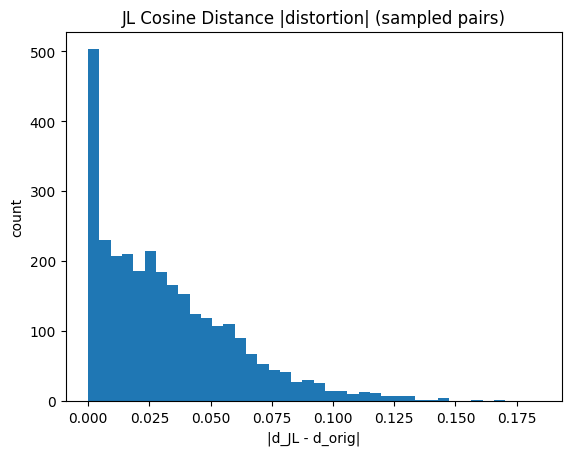

In [6]:
rng = np.random.default_rng(0)
n = X_tfidf.shape[0]
pairs = 3000

idx_a = rng.integers(0, n, size=pairs)
idx_b = rng.integers(0, n, size=pairs)

orig_sim = np.array([X_tfidf[i].multiply(X_tfidf[j]).sum() for i, j in zip(idx_a, idx_b)])
orig_dist = 1.0 - orig_sim

jl_sim = np.sum(X_jl[idx_a] * X_jl[idx_b], axis=1)
jl_dist = 1.0 - jl_sim

distortion = (jl_dist - orig_dist)
abs_distortion = np.abs(distortion)

print("Mean abs distortion:", abs_distortion.mean())
print("95% abs distortion:", np.quantile(abs_distortion, 0.95))

plt.figure()
plt.hist(abs_distortion, bins=40)
plt.title("JL Cosine Distance |distortion| (sampled pairs)")
plt.xlabel("|d_JL - d_orig|")
plt.ylabel("count")
plt.show()

In [7]:
k = len(set(y_true))
t0 = time.perf_counter()

kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
y_km = kmeans.fit_predict(X_jl)  # use JL vectors for speed & fairness

km_time = time.perf_counter() - t0

print("KMeans time:", km_time)

KMeans time: 1.542790004000011


In [8]:
if HDBSCAN_AVAILABLE:
    t0 = time.perf_counter()
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=15,
        min_samples=5,
        metric="euclidean"  # on JL vectors
    )
    y_hdb = clusterer.fit_predict(X_jl)
    hdb_time = time.perf_counter() - t0
    print("HDBSCAN time:", hdb_time)
    print("HDBSCAN clusters (excluding -1 noise):", len(set(y_hdb)) - (1 if -1 in y_hdb else 0))
else:
    y_hdb = None
    hdb_time = None

HDBSCAN time: 7.003871860000004
HDBSCAN clusters (excluding -1 noise): 0


In [9]:
def random_hyperplane_hash(X, hyperplanes):
    """
    X: (n, d) normalized dense vectors
    hyperplanes: (n_bits, d)
    returns: (n, n_bits) boolean array
    """
    proj = X @ hyperplanes.T  # (n, n_bits)
    return proj >= 0.0

def bits_to_int(bit_row):
    """Convert boolean bits to int (for band keys)."""
    out = 0
    for b in bit_row:
        out = (out << 1) | int(b)
    return out

def lsh_candidate_buckets(bits, band_size):
    """
    bits: (n, n_bits) bool
    band_size: how many bits per band
    returns list of dict: each dict maps band_key -> list of indices
    """
    n, n_bits = bits.shape
    assert n_bits % band_size == 0
    n_bands = n_bits // band_size

    tables = []
    for b in range(n_bands):
        start = b * band_size
        end = start + band_size
        table = defaultdict(list)
        for i in range(n):
            key = bits_to_int(bits[i, start:end])
            table[key].append(i)
        tables.append(table)
    return tables

def build_candidate_pairs(tables, max_bucket_size=200):
    """
    From band tables, generate candidate pairs.
    max_bucket_size prevents exploding on huge buckets.
    """
    cand = set()
    for table in tables:
        for key, idxs in table.items():
            if len(idxs) < 2:
                continue
            if len(idxs) > max_bucket_size:
                continue
            # add all pairs
            for i, j in combinations(idxs, 2):
                if i < j:
                    cand.add((i, j))
                else:
                    cand.add((j, i))
    return cand

def connected_components(n, edges):
    """
    n nodes, edges as list of (i,j)
    returns component labels array length n
    """
    parent = np.arange(n)

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    for i, j in edges:
        union(i, j)

    roots = np.array([find(i) for i in range(n)])
    unique_roots, labels = np.unique(roots, return_inverse=True)
    return labels

N_BITS = 96          # total hash bits
BAND_SIZE = 12       # bits per band => 8 bands
COS_THRESHOLD = 0.65 # similarity threshold to add an edge
MAX_BUCKET = 250     # bucket cap

rng = np.random.default_rng(42)
d = X_jl.shape[1]

hyperplanes = rng.normal(size=(N_BITS, d)).astype(np.float32)
hyperplanes /= np.linalg.norm(hyperplanes, axis=1, keepdims=True) + 1e-12

t0 = time.perf_counter()

bits = random_hyperplane_hash(X_jl, hyperplanes)
tables = lsh_candidate_buckets(bits, band_size=BAND_SIZE)
cand_pairs = build_candidate_pairs(tables, max_bucket_size=MAX_BUCKET)

mid = time.perf_counter()

edges = []
for (i, j) in cand_pairs:
    sim = float(np.dot(X_jl[i], X_jl[j]))
    if sim >= COS_THRESHOLD:
        edges.append((i, j))

y_lsh = connected_components(n=X_jl.shape[0], edges=edges)

lsh_time = time.perf_counter() - t0
hash_time = mid - t0
refine_time = lsh_time - hash_time

print("LSH candidates:", len(cand_pairs))
print("LSH edges kept:", len(edges))
print("LSH clusters:", len(np.unique(y_lsh)))
print("LSH time total:", lsh_time, "| hash:", hash_time, "| refine:", refine_time)

LSH candidates: 8272
LSH edges kept: 56
LSH clusters: 2188
LSH time total: 0.4049252259999889 | hash: 0.35592066899999963 | refine: 0.04900455699998929


In [10]:
def purity_score(y_true, y_pred):
    """
    Purity = sum over clusters of max class count in that cluster / N
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    N = len(y_true)
    total = 0
    for c in np.unique(y_pred):
        idx = np.where(y_pred == c)[0]
        if len(idx) == 0:
            continue
        labels, counts = np.unique(y_true[idx], return_counts=True)
        total += counts.max()
    return total / N

def safe_silhouette(X, labels):
    labels = np.asarray(labels)
    # require at least 2 clusters and no single cluster only
    if len(np.unique(labels)) < 2:
        return np.nan
    # if huge N, you can subsample later
    return silhouette_score(X, labels, metric="euclidean")

In [11]:
# ==================================
# Cell 11 — Compute & Compare Results
# ==================================

rows = []

# KMeans
rows.append({
    "method": "KMeans (on JL)",
    "time_sec": km_time,
    "ARI": adjusted_rand_score(y_true, y_km),
    "NMI": normalized_mutual_info_score(y_true, y_km),
    "Purity": purity_score(y_true, y_km),
    "Silhouette": safe_silhouette(X_jl, y_km),
    "n_clusters": len(np.unique(y_km))
})

# HDBSCAN
if HDBSCAN_AVAILABLE and y_hdb is not None:
    # For metrics vs true labels, we keep -1 as its own label (standard)
    rows.append({
        "method": "HDBSCAN (on JL)",
        "time_sec": hdb_time,
        "ARI": adjusted_rand_score(y_true, y_hdb),
        "NMI": normalized_mutual_info_score(y_true, y_hdb),
        "Purity": purity_score(y_true, y_hdb),
        "Silhouette": safe_silhouette(X_jl, y_hdb[y_hdb != -1]) if np.any(y_hdb != -1) else np.nan,
        "n_clusters": len(set(y_hdb)) - (1 if -1 in y_hdb else 0)
    })

# LSH
rows.append({
    "method": "JL + Random-Hyperplane LSH (custom)",
    "time_sec": lsh_time,
    "ARI": adjusted_rand_score(y_true, y_lsh),
    "NMI": normalized_mutual_info_score(y_true, y_lsh),
    "Purity": purity_score(y_true, y_lsh),
    "Silhouette": safe_silhouette(X_jl, y_lsh),
    "n_clusters": len(np.unique(y_lsh))
})

results = pd.DataFrame(rows).sort_values("time_sec")
results

,method,time_sec,ARI,NMI,Purity,Silhouette,n_clusters
2,JL + Random-Hyperplane LSH (custom),0.404925,0.000152,0.304896,1.000000,0.018226,2188
0,KMeans (on JL),1.542790,0.197328,0.231598,0.581956,0.003431,4
1,HDBSCAN (on JL),7.003872,0.000000,0.000000,0.266637,NaN,0


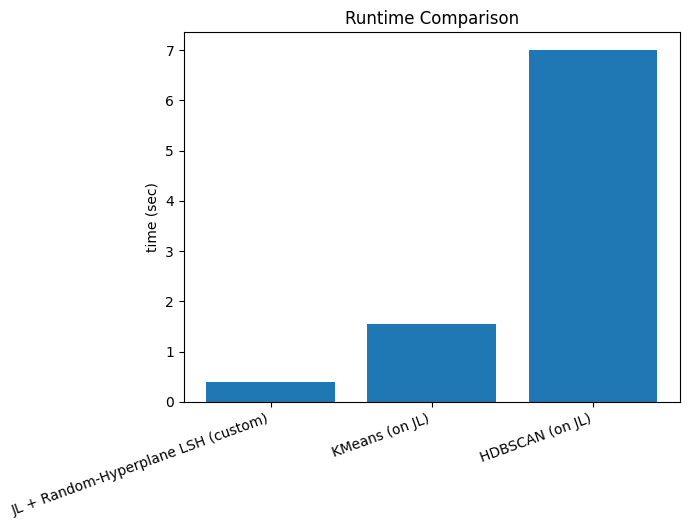

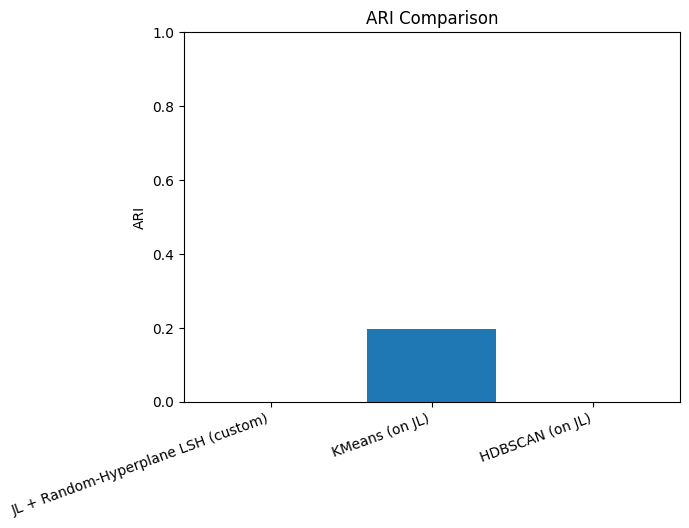

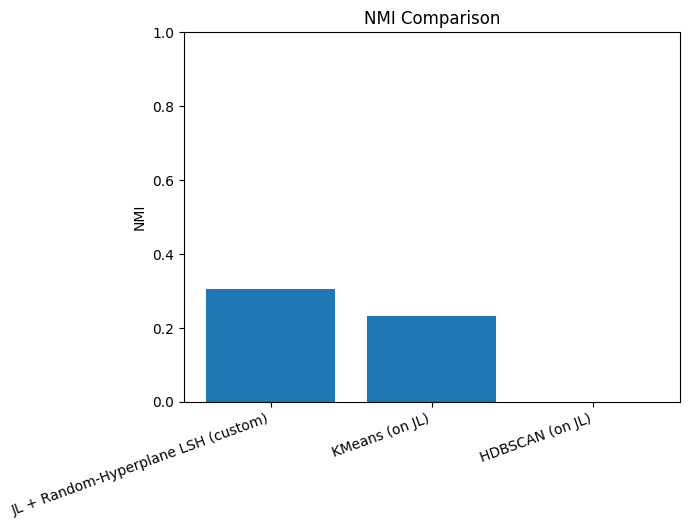

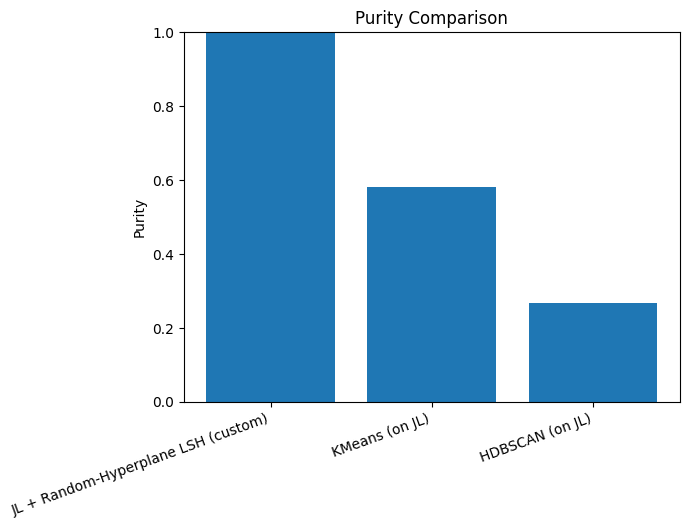

In [12]:
plt.figure()
plt.bar(results["method"], results["time_sec"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("time (sec)")
plt.title("Runtime Comparison")
plt.show()

for metric in ["ARI", "NMI", "Purity"]:
    plt.figure()
    plt.bar(results["method"], results[metric])
    plt.xticks(rotation=20, ha="right")
    plt.ylabel(metric)
    plt.title(f"{metric} Comparison")
    plt.ylim(0, 1.0)
    plt.show()

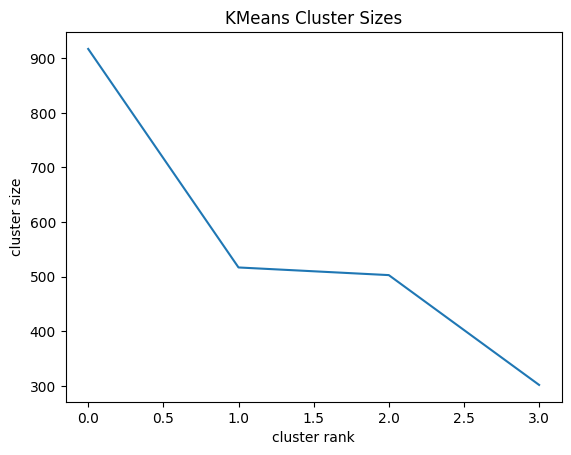

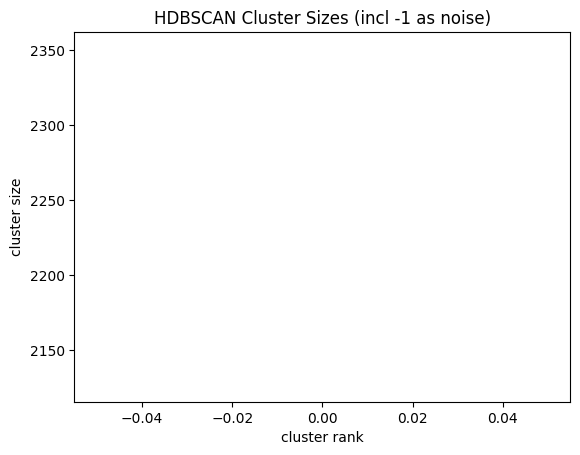

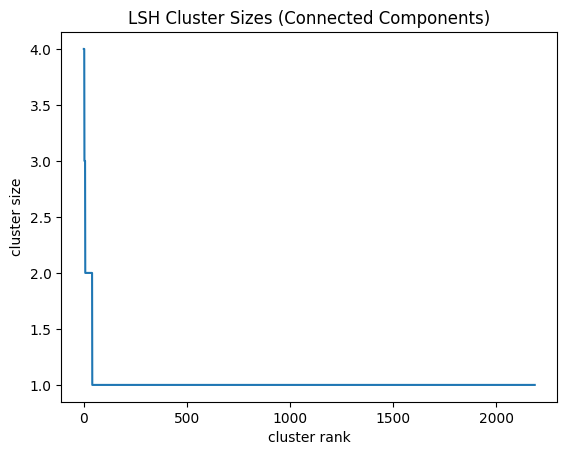

In [13]:

def plot_cluster_sizes(labels, title):
    labels = np.asarray(labels)
    uniq, counts = np.unique(labels, return_counts=True)
    counts = np.sort(counts)[::-1]
    plt.figure()
    plt.plot(counts)
    plt.xlabel("cluster rank")
    plt.ylabel("cluster size")
    plt.title(title)
    plt.show()

plot_cluster_sizes(y_km, "KMeans Cluster Sizes")

if HDBSCAN_AVAILABLE and y_hdb is not None:
    plot_cluster_sizes(y_hdb, "HDBSCAN Cluster Sizes (incl -1 as noise)")

plot_cluster_sizes(y_lsh, "LSH Cluster Sizes (Connected Components)")

In [14]:
# ==========================================================
# Cell 14 — Synthetic Near-Duplicates Test (Optional)
# ==========================================================

def corrupt_text(text, drop_prob=0.15, seed=0):
    rng = np.random.default_rng(seed)
    toks = text.split()
    keep = [t for t in toks if rng.random() > drop_prob]
    if len(keep) < 5:
        keep = toks[:5]
    return " ".join(keep)

# Pick some docs to duplicate
dup_count = 120
rng = np.random.default_rng(123)
base_idx = rng.choice(len(texts), size=dup_count, replace=False)

dup_texts = [corrupt_text(texts[i], drop_prob=0.20, seed=int(i)) for i in base_idx]
aug_texts = texts + dup_texts

# For evaluation: true duplicate pairs (i, i+N)
N0 = len(texts)
dup_pairs = [(int(i), N0 + k) for k, i in enumerate(base_idx)]

# Vectorize + JL again (quick, consistent)
X_aug = vectorizer.fit_transform(aug_texts)
X_aug = normalize(X_aug, norm="l2", axis=1)
X_aug_jl = rp.fit_transform(X_aug)
X_aug_jl = normalize(X_aug_jl, norm="l2", axis=1)

# LSH again
t0 = time.perf_counter()
bits_aug = random_hyperplane_hash(X_aug_jl, hyperplanes)
tables_aug = lsh_candidate_buckets(bits_aug, band_size=BAND_SIZE)
cand_aug = build_candidate_pairs(tables_aug, max_bucket_size=MAX_BUCKET)

edges_aug = []
for (i, j) in cand_aug:
    if float(np.dot(X_aug_jl[i], X_aug_jl[j])) >= COS_THRESHOLD:
        edges_aug.append((i, j))

labels_aug = connected_components(n=X_aug_jl.shape[0], edges=edges_aug)
dup_time = time.perf_counter() - t0

# Duplicate recall: fraction of dup pairs that land in same component
hits = sum(1 for a, b in dup_pairs if labels_aug[a] == labels_aug[b])
dup_recall = hits / len(dup_pairs)

print("Duplicate recall (LSH components):", dup_recall)
print("Time (LSH on augmented):", dup_time)

Duplicate recall (LSH components): 0.8083333333333333
Time (LSH on augmented): 0.5892111449999788
